In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Cargar el dataset
file_path = "/content/drive/MyDrive/ASE/ASE2/TABLAFINAL_LARGA FINAL FINAL FINAL Resumida.csv"  # Ajusta la ruta si es necesario
df = pd.read_csv(file_path)

# Crear variable categórica para la medalla ganada
def categorizar_medalla(row):
    if row["MEDALLAS_DE_ORO"] > 0:
        return "oro"
    elif row["MEDALLAS_TOTALES"] > 0:
        return "otra_medalla"  # Incluye plata y bronce
    else:
        return "ninguna"

df["CATEGORIA_MEDALLA"] = df.apply(categorizar_medalla, axis=1)

# Eliminar valores nulos en medallas
df_clean = df.dropna(subset=["MEDALLAS_TOTALES", "MEDALLAS_DE_ORO"])

# Seleccionar variables numéricas para normalización
num_vars = ["PIB_POR_PAIS", "TASA_MORTALIDAD_INFANTIL", "POBLACION_TOTAL",
            "POBLACION_0_14", "POBLACION_20_24_VARONES", "POBLACION_20_24_MUJERES"]

# Imputar valores nulos en PIB y tasa de mortalidad infantil con la mediana
df_clean[num_vars] = df_clean[num_vars].fillna(df_clean[num_vars].median())

# Normalizar variables numéricas
scaler = StandardScaler()
df_clean[num_vars] = scaler.fit_transform(df_clean[num_vars])

# Codificar la variable objetivo
label_encoder = LabelEncoder()
df_clean["CATEGORIA_MEDALLA"] = label_encoder.fit_transform(df_clean["CATEGORIA_MEDALLA"])

# Separar en variables predictoras (X) y variable objetivo (y)
X = df_clean[num_vars]
y = df_clean["CATEGORIA_MEDALLA"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Crear y entrenar el modelo de regresión logística multinomial
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=500)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precisión del modelo: {accuracy:.4f}")
print("Matriz de confusión:")
print(conf_matrix)


Precisión del modelo: 0.7692
Matriz de confusión:
[[455   7   0]
 [ 76  55   1]
 [ 63   6   0]]


<ipython-input-1-8909ec601ae9>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[num_vars] = df_clean[num_vars].fillna(df_clean[num_vars].median())
<ipython-input-1-8909ec601ae9>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[num_vars] = scaler.fit_transform(df_clean[num_vars])
<ipython-input-1-8909ec601ae9>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

Precisión del modelo: 0.8462


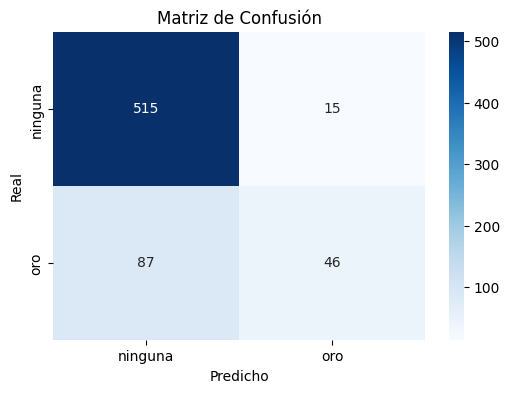

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Cargar el dataset
file_path = "/content/drive/MyDrive/ASE/ASE2/TABLAFINAL_LARGA FINAL FINAL FINAL Resumida.csv"  # Ajusta la ruta si es necesario
df = pd.read_csv(file_path)

# Crear variable categórica para la medalla ganada
def categorizar_medalla(row):
    if row["MEDALLAS_DE_ORO"] > 0:
        return "oro"
    else:
        return "ninguna"

df["CATEGORIA_MEDALLA"] = df.apply(categorizar_medalla, axis=1)

# Eliminar valores nulos en medallas
df_clean = df.dropna(subset=["MEDALLAS_TOTALES", "MEDALLAS_DE_ORO"]).copy()

# Seleccionar variables numéricas para normalización
num_vars = ["PIB_POR_PAIS", "TASA_MORTALIDAD_INFANTIL", "POBLACION_TOTAL",
            "POBLACION_0_14", "POBLACION_20_24_VARONES", "POBLACION_20_24_MUJERES"]

# Imputar valores nulos en PIB y tasa de mortalidad infantil con la mediana
df_clean.loc[:, num_vars] = df_clean[num_vars].fillna(df_clean[num_vars].median())

# Normalizar variables numéricas
scaler = StandardScaler()
df_clean.loc[:, num_vars] = scaler.fit_transform(df_clean[num_vars])

# Codificar la variable objetivo
label_encoder = LabelEncoder()
df_clean["CATEGORIA_MEDALLA"] = label_encoder.fit_transform(df_clean["CATEGORIA_MEDALLA"])

# Separar en variables predictoras (X) y variable objetivo (y)
X = df_clean[num_vars]
y = df_clean["CATEGORIA_MEDALLA"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Crear y entrenar el modelo de regresión logística multinomial
model = LogisticRegression(solver="lbfgs", max_iter=500)  # Se elimina multi_class="multinomial"
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precisión del modelo: {accuracy:.4f}")

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


Precisión del modelo: 0.7919


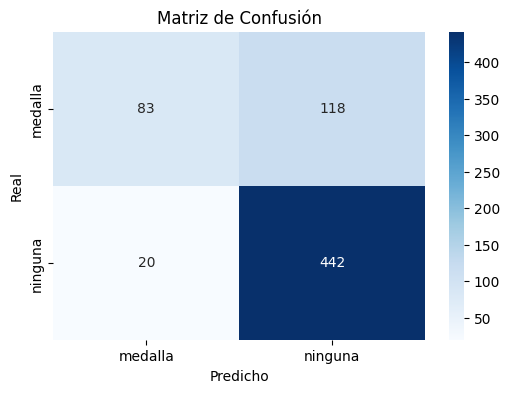

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Cargar el dataset
file_path = "/content/drive/MyDrive/ASE/ASE2/TABLAFINAL_LARGA FINAL FINAL FINAL Resumida.csv"  # Ajusta la ruta si es necesario
df = pd.read_csv(file_path)

# Crear variable categórica para la medalla ganada
def categorizar_medalla(row):
    if row["MEDALLAS_TOTALES"] > 0:
        return "medalla"  # Incluye plata y bronce
    else:
        return "ninguna"

df["CATEGORIA_MEDALLA"] = df.apply(categorizar_medalla, axis=1)

# Eliminar valores nulos en medallas
df_clean = df.dropna(subset=["MEDALLAS_TOTALES", "MEDALLAS_DE_ORO"]).copy()

# Seleccionar variables numéricas para normalización
num_vars = ["PIB_POR_PAIS", "TASA_MORTALIDAD_INFANTIL", "POBLACION_TOTAL",
            "POBLACION_0_14", "POBLACION_20_24_VARONES", "POBLACION_20_24_MUJERES"]

# Imputar valores nulos en PIB y tasa de mortalidad infantil con la mediana
df_clean.loc[:, num_vars] = df_clean[num_vars].fillna(df_clean[num_vars].median())

# Normalizar variables numéricas
scaler = StandardScaler()
df_clean.loc[:, num_vars] = scaler.fit_transform(df_clean[num_vars])

# Codificar la variable objetivo
label_encoder = LabelEncoder()
df_clean["CATEGORIA_MEDALLA"] = label_encoder.fit_transform(df_clean["CATEGORIA_MEDALLA"])

# Separar en variables predictoras (X) y variable objetivo (y)
X = df_clean[num_vars]
y = df_clean["CATEGORIA_MEDALLA"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Crear y entrenar el modelo de regresión logística multinomial
model = LogisticRegression(solver="lbfgs", max_iter=500)  # Se elimina multi_class="multinomial"
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precisión del modelo: {accuracy:.4f}")

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


In [ ]:
# Hacer predicciones en todo el dataset
df_clean["MEDALLA_PREDICHA"] = model.predict(X)

# Decodificar las categorías de medalla
df_clean["MEDALLA_PREDICHA"] = label_encoder.inverse_transform(df_clean["MEDALLA_PREDICHA"])
##df_clean["CATEGORIA_MEDALLA"] = label_encoder.inverse_transform(df_clean["CATEGORIA_MEDALLA"])

# Agrupar por país y año para obtener la suma de medallas reales
medallas_reales = df_clean.groupby(["COUNTRY", "ANOO"])["MEDALLAS_TOTALES"].sum().reset_index()

# Contar el número de medallas predichas por país y año
medallas_predichas = df_clean.groupby(["COUNTRY", "ANOO"])["MEDALLA_PREDICHA"].value_counts().unstack().fillna(0).reset_index()

# Unir ambas tablas
tabla_final = medallas_reales.merge(medallas_predichas, on=["COUNTRY", "ANOO"], how="left")

# Renombrar columnas para mayor claridad
tabla_final.rename(columns={"MEDALLAS_TOTALES": "MEDALLAS_REALES",
                            "ninguna": "PREDICCION_SIN_MEDALLA",
                            "oro": "PREDICCION_ORO",
                            "medalla": "PREDICCION_MEDALLA"}, inplace=True)

# Mostrar la tabla final
print(tabla_final.head())
# Exportar a un archivo Excel
output_file = "medallas_predichas_vs_reales.xlsx"
tabla_final.to_excel(output_file, index=False)

print(f"Archivo guardado como: {output_file}")



       COUNTRY  ANOO  MEDALLAS_REALES  PREDICCION_MEDALLA  \
0  Afghanistan  1960              0.0                 0.0   
1  Afghanistan  1964              0.0                 0.0   
2  Afghanistan  1968              0.0                 0.0   
3  Afghanistan  1972              0.0                 0.0   
4  Afghanistan  1976              0.0                 0.0   

   PREDICCION_SIN_MEDALLA  
0                     1.0  
1                     1.0  
2                     1.0  
3                     1.0  
4                     1.0  
Archivo guardado como: medallas_predichas_vs_reales.xlsx



=== 1. CARGANDO Y PREPARANDO LOS DATOS ===

Datos cargados correctamente. Dimensiones: (3519, 10)

Distribución de categorías de medallas:
CATEGORIA_MEDALLA
ninguna    0.811878
oro        0.188122
Name: proportion, dtype: float64

=== 2. LIMPIEZA Y PREPROCESAMIENTO ===

Registros después de eliminar nulos en medallas: 3312/3519

Valores nulos antes de imputación:
PIB_POR_PAIS                526
TASA_MORTALIDAD_INFANTIL    480
POBLACION_TOTAL               0
POBLACION_0_14                0
POBLACION_20_24_VARONES       0
POBLACION_20_24_MUJERES       0
dtype: int64

Valores nulos después de imputación:
PIB_POR_PAIS                0
TASA_MORTALIDAD_INFANTIL    0
POBLACION_TOTAL             0
POBLACION_0_14              0
POBLACION_20_24_VARONES     0
POBLACION_20_24_MUJERES     0
dtype: int64

=== 3. ENTRENAMIENTO Y EVALUACIÓN DEL MODELO ===

Tamaño del conjunto de entrenamiento: (2649, 6)
Tamaño del conjunto de prueba: (663, 6)

Precisión del modelo: 0.8462

Reporte de Clasificación:
 

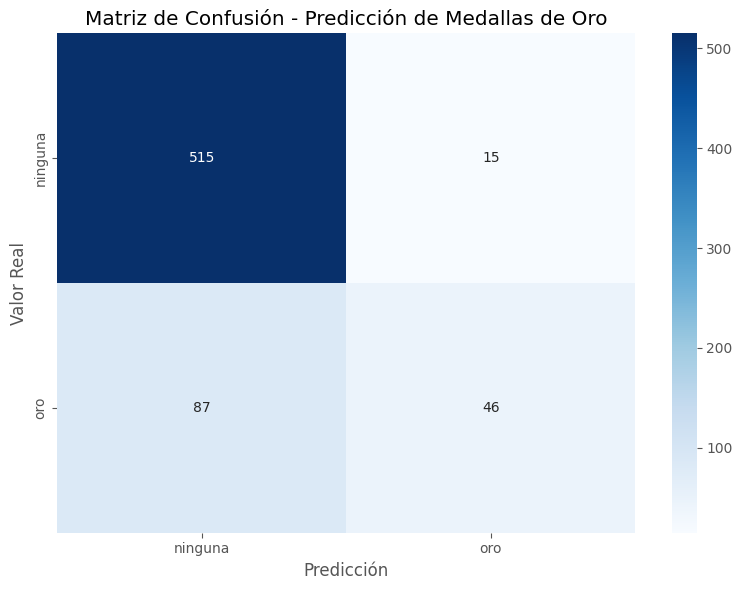


=== 4. ANÁLISIS DE LA MATRIZ DE CONFUSIÓN ===


=== 5. PREDICCIONES POR AÑO Y PAÍS ===

Resumen de precisión por año:
ANOO
1960    0.0
1964    0.0
1968    0.0
1972    0.0
1976    0.0
1980    0.0
1984    0.0
1988    0.0
1992    0.0
1996    0.0
2000    0.0
2004    0.0
2008    0.0
2012    0.0
2016    0.0
2020    0.0
Name: COINCIDE, dtype: float64

Año 1960:
                 COUNTRY  CATEGORIA_MEDALLA PREDICCION_MEDALLA  COINCIDE
0            Afghanistan                NaN            ninguna     False
17               Albania                NaN            ninguna     False
34               Algeria                NaN            ninguna     False
51               Andorra                NaN            ninguna     False
68                Angola                NaN            ninguna     False
85   Antigua and Barbuda                NaN            ninguna     False
102            Argentina                NaN            ninguna     False
119              Armenia                NaN            nin

<ipython-input-4-f6ea6322ac9d>:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coeficiente", y="Variable", data=coefficients, palette="viridis")


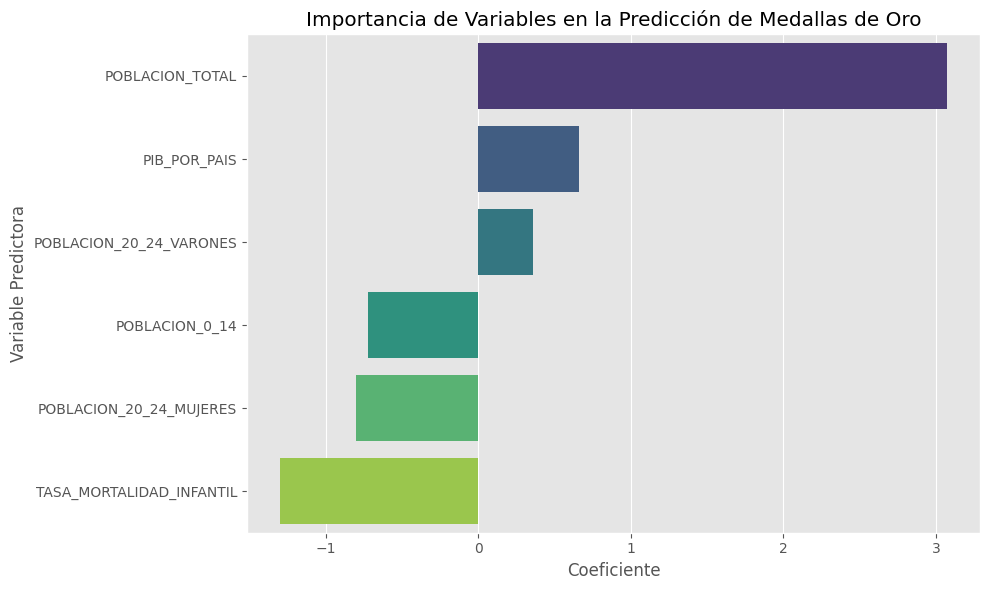


=== ANÁLISIS FINALIZADO ===


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuración inicial
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

## 1. Carga y Preparación de Datos
print("\n=== 1. CARGANDO Y PREPARANDO LOS DATOS ===\n")

# Cargar el dataset
file_path = "/content/drive/MyDrive/ASE/ASE2/TABLAFINAL_LARGA FINAL FINAL FINAL Resumida.csv"
try:
    df = pd.read_csv(file_path)
    print(f"Datos cargados correctamente. Dimensiones: {df.shape}")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")
    exit()

# Crear variable categórica para la medalla ganada
def categorizar_medalla(row):
    if row["MEDALLAS_DE_ORO"] > 0:
        return "oro"
    else:
        return "ninguna"

df["CATEGORIA_MEDALLA"] = df.apply(categorizar_medalla, axis=1)

# Verificar distribución de clases
print("\nDistribución de categorías de medallas:")
print(df["CATEGORIA_MEDALLA"].value_counts(normalize=True))

## 2. Limpieza y Preprocesamiento
print("\n=== 2. LIMPIEZA Y PREPROCESAMIENTO ===\n")

# Eliminar valores nulos en medallas
df_clean = df.dropna(subset=["MEDALLAS_TOTALES", "MEDALLAS_DE_ORO"]).copy()
print(f"Registros después de eliminar nulos en medallas: {len(df_clean)}/{len(df)}")

# Seleccionar variables numéricas para normalización
num_vars = ["PIB_POR_PAIS", "TASA_MORTALIDAD_INFANTIL", "POBLACION_TOTAL",
            "POBLACION_0_14", "POBLACION_20_24_VARONES", "POBLACION_20_24_MUJERES"]

# Imputar valores nulos con la mediana
print("\nValores nulos antes de imputación:")
print(df_clean[num_vars].isnull().sum())

df_clean.loc[:, num_vars] = df_clean[num_vars].fillna(df_clean[num_vars].median())

print("\nValores nulos después de imputación:")
print(df_clean[num_vars].isnull().sum())

# Normalizar variables numéricas
scaler = StandardScaler()
df_clean.loc[:, num_vars] = scaler.fit_transform(df_clean[num_vars])

# Codificar la variable objetivo
label_encoder = LabelEncoder()
df_clean["CATEGORIA_MEDALLA"] = label_encoder.fit_transform(df_clean["CATEGORIA_MEDALLA"])

## 3. Modelado y Evaluación
print("\n=== 3. ENTRENAMIENTO Y EVALUACIÓN DEL MODELO ===\n")

# Separar en variables predictoras (X) y variable objetivo (y)
X = df_clean[num_vars]
y = df_clean["CATEGORIA_MEDALLA"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

# Crear y entrenar el modelo de regresión logística
model = LogisticRegression(solver="lbfgs", max_iter=500)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrecisión del modelo: {accuracy:.4f}")

# Reporte de clasificación detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Predicción de Medallas de Oro")
plt.tight_layout()
plt.show()

## 4. Análisis de la Matriz de Confusión
print("\n=== 4. ANÁLISIS DE LA MATRIZ DE CONFUSIÓN ===\n")
"""
La matriz de confusión muestra:

1. Verdaderos Negativos (Esquina superior izquierda):
   - Países que NO ganaron medallas de oro y fueron correctamente predichos como tales.

2. Falsos Positivos (Esquina superior derecha):
   - Países que NO ganaron medallas de oro pero fueron incorrectamente predichos como ganadores.
   - Estos son errores Tipo I (falsas alarmas).

3. Falsos Negativos (Esquina inferior izquierda):
   - Países que SÍ ganaron medallas de oro pero fueron incorrectamente predichos como no ganadores.
   - Estos son errores Tipo II (omisiones).

4. Verdaderos Positivos (Esquina inferior derecha):
   - Países que SÍ ganaron medallas de oro y fueron correctamente predichos como tales.

Interpretación:
- Un buen modelo tendría altos valores en la diagonal principal (verdaderos positivos y negativos)
  y bajos valores en la diagonal secundaria (errores).
- El desbalance de clases (más casos de "ninguna" que de "oro") puede afectar la interpretación.
"""

## 5. Predicciones por Año y País
print("\n=== 5. PREDICCIONES POR AÑO Y PAÍS ===\n")

# Aplicar el modelo a todo el dataframe
df_clean["PREDICCION_MEDALLA"] = model.predict(X)
df_clean["PREDICCION_MEDALLA"] = label_encoder.inverse_transform(df_clean["PREDICCION_MEDALLA"])

# Crear tabla comparativa por año y país
comparison_table = df_clean[["ANOO", "COUNTRY", "CATEGORIA_MEDALLA", "PREDICCION_MEDALLA"]].copy()
comparison_table["COINCIDE"] = comparison_table["CATEGORIA_MEDALLA"] == comparison_table["PREDICCION_MEDALLA"]

# Convertir la categoría codificada de vuelta a texto
comparison_table["CATEGORIA_MEDALLA"] = comparison_table["CATEGORIA_MEDALLA"].map(
    {label: category for category, label in enumerate(label_encoder.classes_)}
)

# Mostrar resumen por año
print("Resumen de precisión por año:")
yearly_accuracy = comparison_table.groupby("ANOO")["COINCIDE"].mean()
print(yearly_accuracy)

# Mostrar tabla detallada para los primeros 5 años
for year in sorted(comparison_table["ANOO"].unique())[:5]:
    print(f"\nAño {year}:")
    year_data = comparison_table[comparison_table["ANOO"] == year]
    print(year_data[["COUNTRY", "CATEGORIA_MEDALLA", "PREDICCION_MEDALLA", "COINCIDE"]].head(10))

# Guardar resultados completos
output_path = "/content/drive/MyDrive/ASE/ASE2/resultados_prediccion_medallas.csv"
comparison_table.to_csv(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

## 6. Análisis de Coeficientes
print("\n=== 6. ANÁLISIS DE COEFICIENTES DEL MODELO ===\n")

coefficients = pd.DataFrame({
    "Variable": num_vars,
    "Coeficiente": model.coef_[0]
}).sort_values("Coeficiente", ascending=False)

print("Coeficientes del modelo logístico:")
print(coefficients)

# Visualización de coeficientes
plt.figure(figsize=(10, 6))
sns.barplot(x="Coeficiente", y="Variable", data=coefficients, palette="viridis")
plt.title("Importancia de Variables en la Predicción de Medallas de Oro")
plt.xlabel("Coeficiente")
plt.ylabel("Variable Predictora")
plt.tight_layout()
plt.show()

print("\n=== ANÁLISIS FINALIZADO ===")